Epoch 1/20
26064/26064 [==============================] - 65s 2ms/step - loss: 0.0426 - accuracy: 0.9838 - val_loss: 0.0226 - val_accuracy: 0.9910
Epoch 2/20
26064/26064 [==============================] - 56s 2ms/step - loss: 0.0240 - accuracy: 0.9904 - val_loss: 0.0188 - val_accuracy: 0.9936
Epoch 3/20
26064/26064 [==============================] - 59s 2ms/step - loss: 0.0209 - accuracy: 0.9922 - val_loss: 0.0158 - val_accuracy: 0.9935
Epoch 4/20
26064/26064 [==============================] - 62s 2ms/step - loss: 0.0191 - accuracy: 0.9928 - val_loss: 0.0167 - val_accuracy: 0.9935
Epoch 5/20
26064/26064 [==============================] - 64s 2ms/step - loss: 0.0177 - accuracy: 0.9938 - val_loss: 0.0179 - val_accuracy: 0.9943
Epoch 6/20
26064/26064 [==============================] - 60s 2ms/step - loss: 0.0168 - accuracy: 0.9943 - val_loss: 0.0194 - val_accuracy: 0.9939
Epoch 7/20
26064/26064 [==============================] - 345s 13ms/step - loss: 0.0167 - accuracy: 0.9945 - val_loss:

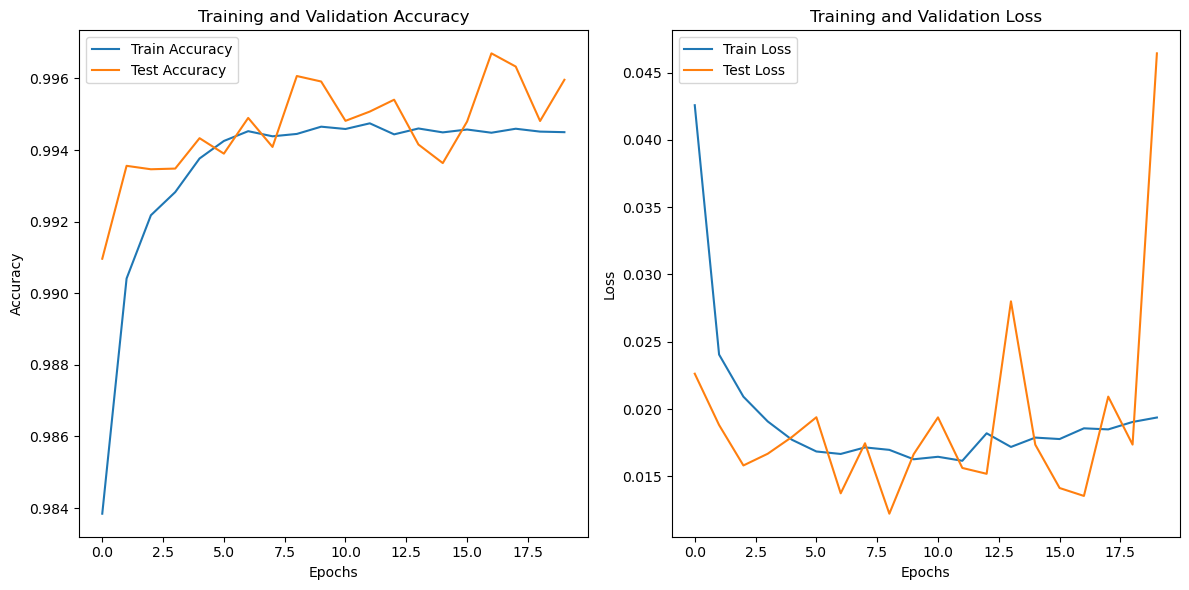

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

data = pd.read_csv('dataset.csv')


X = data.drop(columns=[' Label'])
y = data[' Label']


X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)


label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


scaler = StandardScaler()
X = scaler.fit_transform(X)


num_features = X.shape[1]
grid_size = int(np.ceil(np.sqrt(num_features)))
X = np.pad(X, ((0, 0), (0, grid_size**2 - num_features)), 'constant')
X = X.reshape(X.shape[0], grid_size, grid_size, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(grid_size, grid_size, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(y)), activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


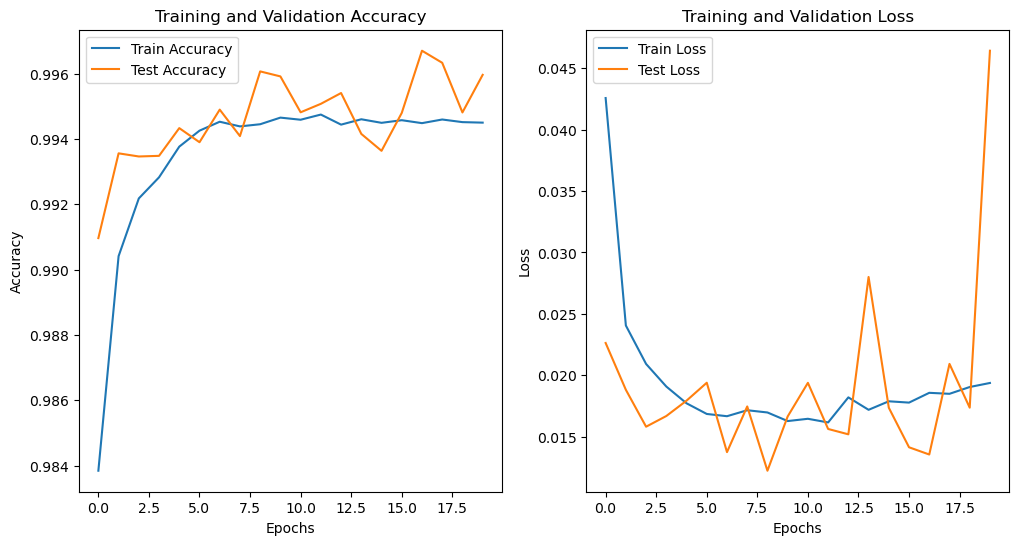

Chart saved as C:\Users\aadil\Downloads\training_validation_metrics.png


In [14]:
# Plot and save the charts
plt.figure(figsize=(12, 6))

# Training and Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Save the figure
# Save the figure with a specified path
output_path = r"C:\Users\aadil\Downloads\training_validation_metrics.png"  # Use raw string to handle Windows paths
plt.savefig(output_path, dpi=300, format='png', bbox_inches='tight')
plt.show()

print(f"Chart saved as {output_path}")




Classification Report:

              precision    recall  f1-score   support

      BENIGN     0.9986    0.9950    0.9968    125815
        DDoS     0.9995    0.9945    0.9970     25604
         DoS     0.9836    0.9994    0.9915     38929
    PortScan     0.9999    0.9970    0.9985     18164

    accuracy                         0.9960    208512
   macro avg     0.9954    0.9965    0.9959    208512
weighted avg     0.9960    0.9960    0.9960    208512

Weighted F1 Score: 0.9960
Weighted Precision: 0.9960
Weighted Recall: 0.9960


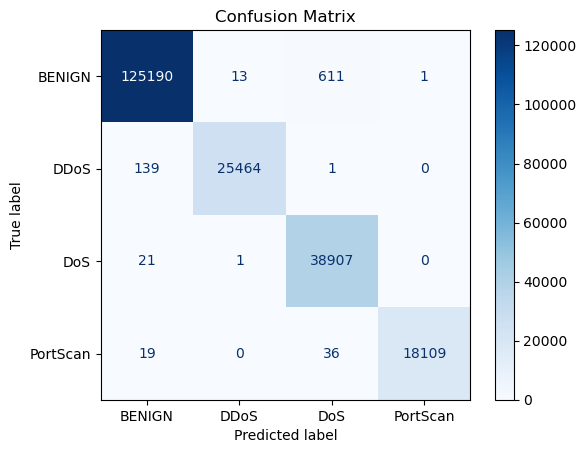

Confusion Matrix saved as C:\Users\aadil\Downloads\confusion_matrix.png


In [18]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, ConfusionMatrixDisplay

# Predict on the test set
y_pred = np.argmax(model.predict(X_test), axis=1)

# Classification report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4)
print("Classification Report:\n")
print(report)

# F1 Score, Precision, and Recall
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_encoder.classes_, cmap='Blues')
plt.title('Confusion Matrix')
confusion_matrix_path = r"C:\Users\aadil\Downloads\confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix saved as {confusion_matrix_path}")


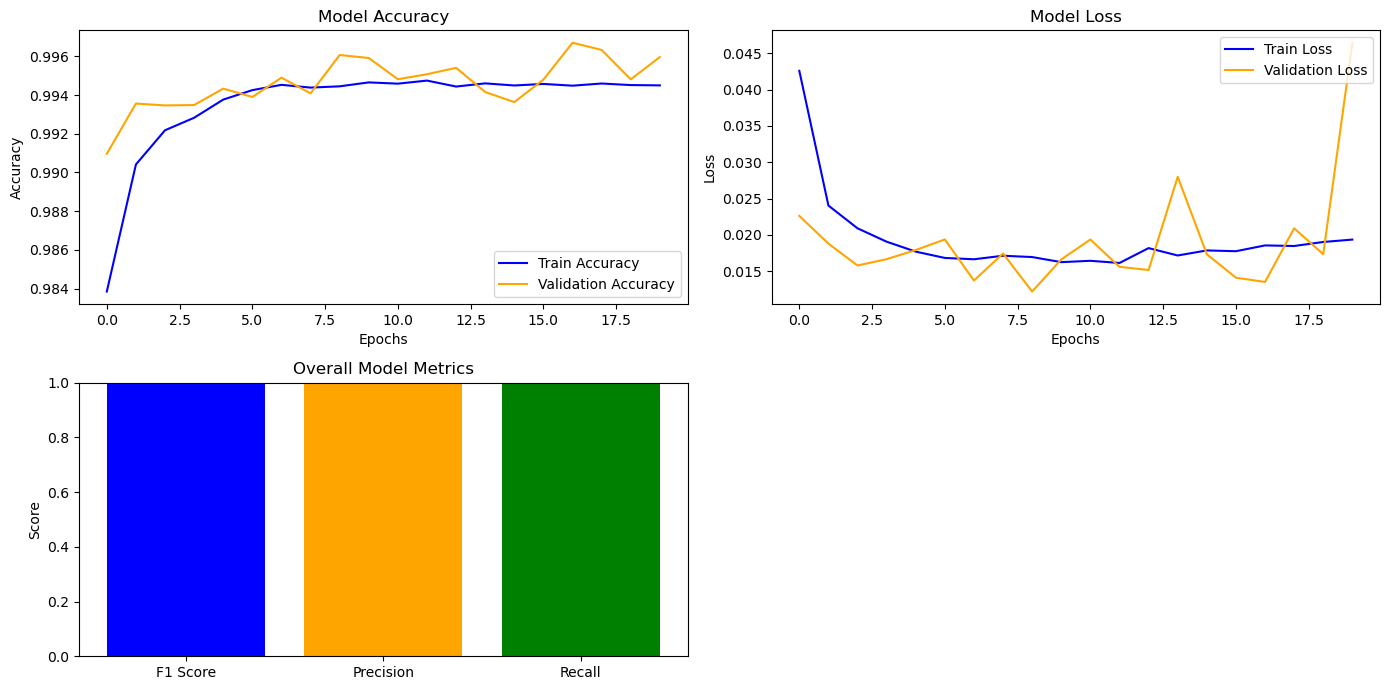

Enhanced performance graph saved as C:\Users\aadil\Downloads\model_performance_summary.png


In [20]:
plt.figure(figsize=(14, 7))

# Subplot 1: Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Subplot 2: Loss
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Subplot 3: F1-Score, Precision, and Recall (using Bar Graph)
plt.subplot(2, 2, 3)
metrics = ['F1 Score', 'Precision', 'Recall']
values = [f1, precision, recall]
plt.bar(metrics, values, color=['blue', 'orange', 'green'])
plt.ylim([0, 1])
plt.title('Overall Model Metrics')
plt.ylabel('Score')

# Save the enhanced graph
output_path = r"C:\Users\aadil\Downloads\model_performance_summary.png"
plt.tight_layout()
plt.savefig(output_path, dpi=300, format='png', bbox_inches='tight')
plt.show()

print(f"Enhanced performance graph saved as {output_path}")
